In [1]:
import os
print(os.listdir('/kaggle/input/'))
for folder in os.listdir('/kaggle/input/'):
    print(os.listdir(f'/kaggle/input/{folder}'))

['datasets']
['cherngs']


In [2]:
import os
# Correct path
for folder in os.listdir('/kaggle/input/datasets/cherngs/'):
    print(folder)

heart-disease-cleveland-uci


In [3]:
import os
print(os.listdir('/kaggle/input/datasets/cherngs/heart-disease-cleveland-uci/'))

['heart_cleveland_upload.csv']


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('/kaggle/input/datasets/cherngs/heart-disease-cleveland-uci/heart_cleveland_upload.csv')
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (297, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [5]:
# Basic info
print("Dataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB
None

Missing Values:
age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,2.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,0.602694,0.676768,0.835017,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,0.956690,0.499340
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000


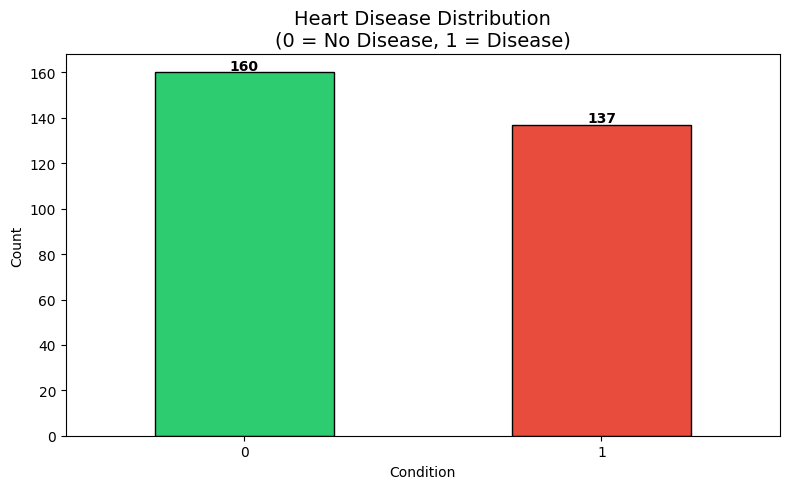


No Disease: 160 patients
Has Disease: 137 patients


In [6]:
# Target distribution
plt.figure(figsize=(8,5))
colors = ['#2ecc71', '#e74c3c']
df['condition'].value_counts().plot(kind='bar', color=colors, edgecolor='black')
plt.title('Heart Disease Distribution\n(0 = No Disease, 1 = Disease)', fontsize=14)
plt.xlabel('Condition')
plt.ylabel('Count')
plt.xticks(rotation=0)
for i, v in enumerate(df['condition'].value_counts()):
    plt.text(i, v + 1, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
print(f"\nNo Disease: {df['condition'].value_counts()[0]} patients")
print(f"Has Disease: {df['condition'].value_counts()[1]} patients")

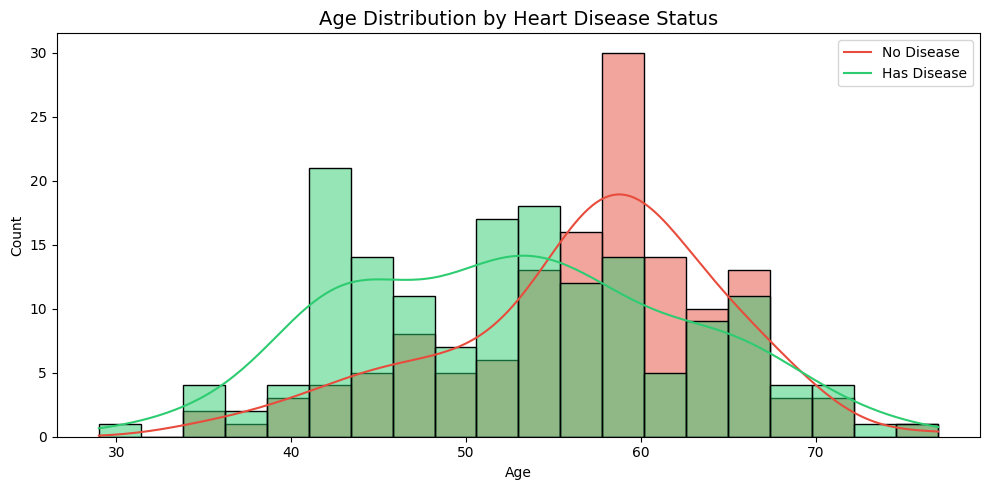

In [7]:
# Age vs Heart Disease
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='age', hue='condition', bins=20, kde=True,
             palette={0:'#2ecc71', 1:'#e74c3c'})
plt.title('Age Distribution by Heart Disease Status', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(['No Disease', 'Has Disease'])
plt.tight_layout()
plt.show()

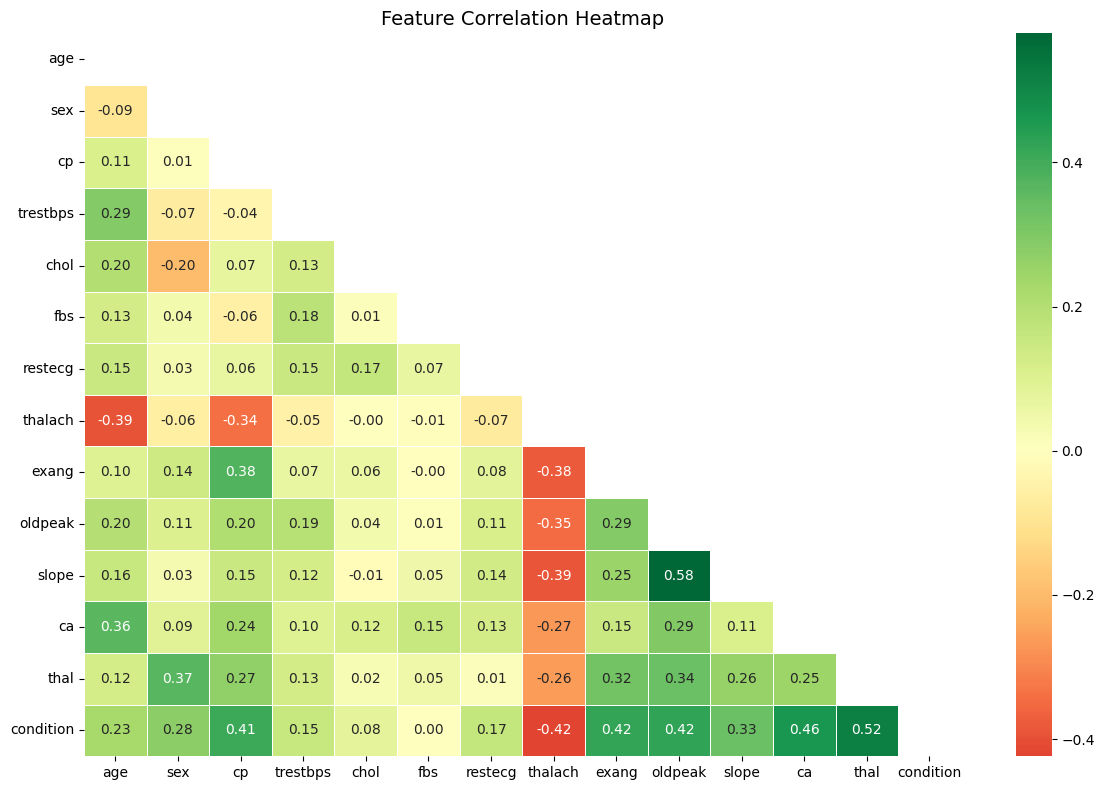

In [8]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

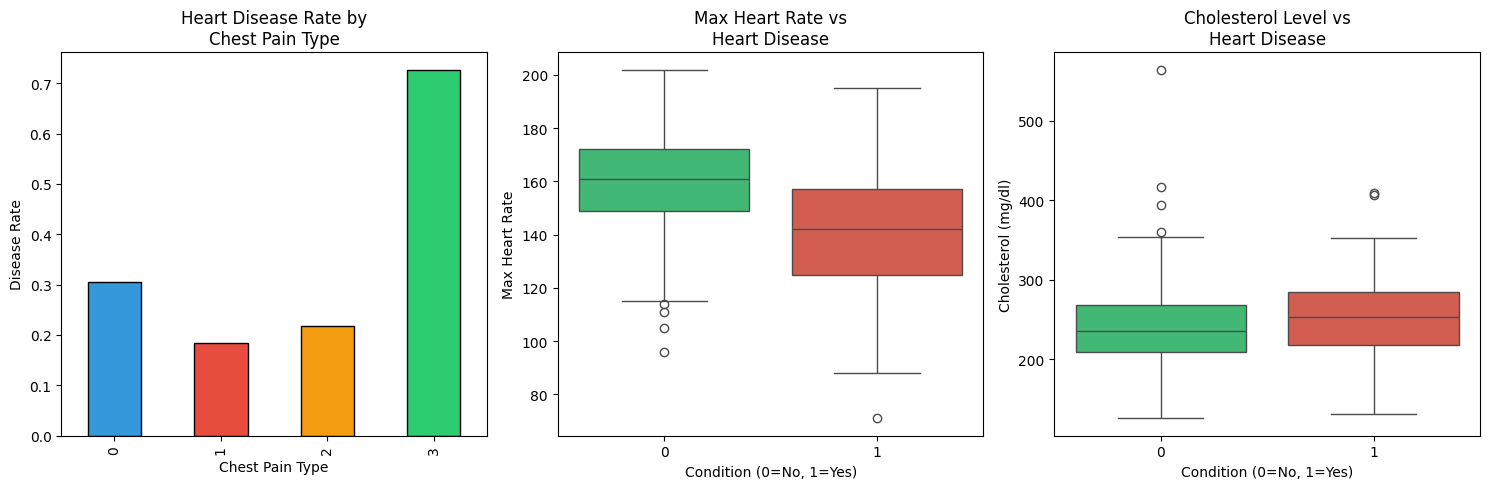

In [9]:
# Key features analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Chest pain type
df.groupby('cp')['condition'].mean().plot(kind='bar', ax=axes[0],
    color=['#3498db','#e74c3c','#f39c12','#2ecc71'], edgecolor='black')
axes[0].set_title('Heart Disease Rate by\nChest Pain Type')
axes[0].set_xlabel('Chest Pain Type')
axes[0].set_ylabel('Disease Rate')

# Max Heart Rate
sns.boxplot(x='condition', y='thalach', data=df, ax=axes[1],
            palette={'0':'#2ecc71', '1':'#e74c3c'})
axes[1].set_title('Max Heart Rate vs\nHeart Disease')
axes[1].set_xlabel('Condition (0=No, 1=Yes)')
axes[1].set_ylabel('Max Heart Rate')

# Cholesterol
sns.boxplot(x='condition', y='chol', data=df, ax=axes[2],
            palette={'0':'#2ecc71', '1':'#e74c3c'})
axes[2].set_title('Cholesterol Level vs\nHeart Disease')
axes[2].set_xlabel('Condition (0=No, 1=Yes)')
axes[2].set_ylabel('Cholesterol (mg/dl)')

plt.tight_layout()
plt.show()

In [10]:
# Features and target
X = df.drop('condition', axis=1)
y = df['condition']

print("Features used:", list(X.columns))
print(f"\nTotal samples: {len(df)}")
print(f"Features: {X.shape[1]}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTraining samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("\n✅ Data preprocessing complete!")

Features used: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Total samples: 297
Features: 13

Training samples: 237
Testing samples: 60

✅ Data preprocessing complete!


In [11]:
# Train 3 models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: {acc*100:.2f}% accuracy")

best_model_name = max(results, key=results.get)
print(f"\n🏆 Best Model: {best_model_name} ({results[best_model_name]*100:.2f}%)")

Logistic Regression: 91.67% accuracy
Random Forest: 88.33% accuracy
Gradient Boosting: 86.67% accuracy

🏆 Best Model: Logistic Regression (91.67%)


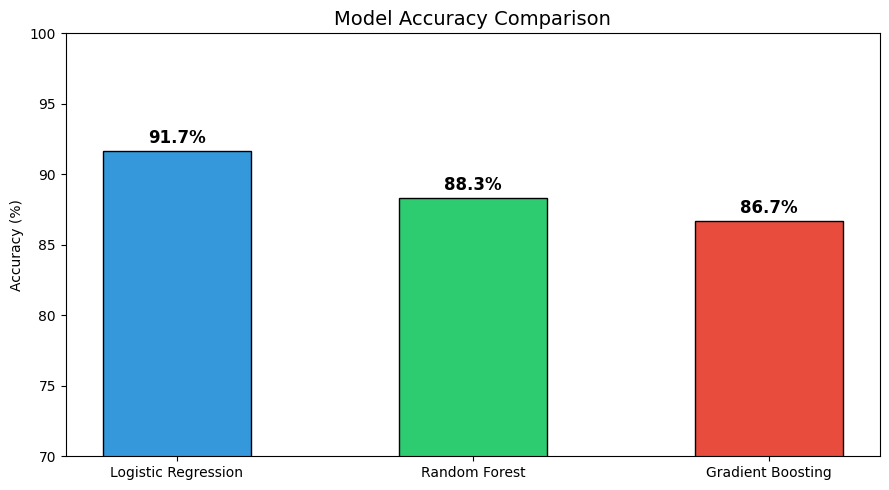

In [12]:
# Visualize model comparison
plt.figure(figsize=(9,5))
colors = ['#3498db', '#2ecc71', '#e74c3c']
bars = plt.bar(results.keys(), [v*100 for v in results.values()],
               color=colors, edgecolor='black', width=0.5)
plt.title('Model Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy (%)')
plt.ylim(70, 100)
for bar, acc in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
             f'{acc*100:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

=== Logistic Regression — Detailed Report ===

              precision    recall  f1-score   support

  No Disease       0.86      1.00      0.93        32
 Has Disease       1.00      0.82      0.90        28

    accuracy                           0.92        60
   macro avg       0.93      0.91      0.91        60
weighted avg       0.93      0.92      0.92        60



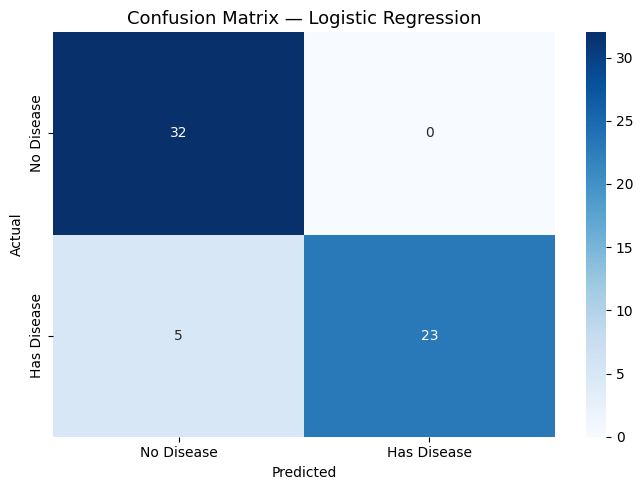

In [13]:
# Best model detailed report
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)

print(f"=== {best_model_name} — Detailed Report ===\n")
print(classification_report(y_test, y_pred_best,
      target_names=['No Disease', 'Has Disease']))

# Confusion Matrix
plt.figure(figsize=(7,5))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Has Disease'],
            yticklabels=['No Disease', 'Has Disease'])
plt.title(f'Confusion Matrix — {best_model_name}', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

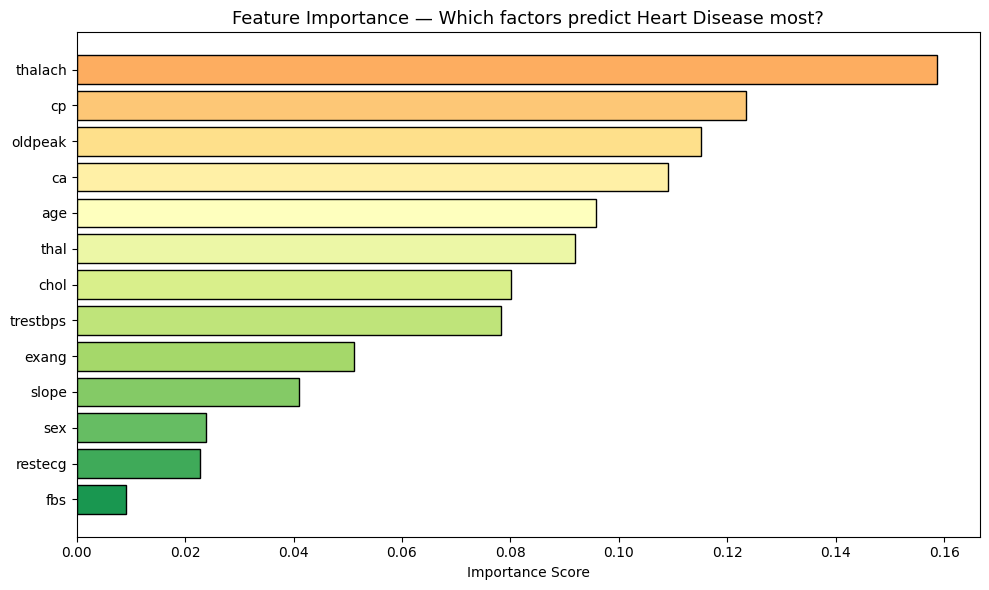


Top 3 Most Important Features:
  thalach: 0.1587
  cp: 0.1234
  oldpeak: 0.1151


In [14]:
# Feature Importance (Random Forest)
rf_model = models['Random Forest']
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
colors_fi = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(feature_importance)))
bars = plt.barh(feature_importance['feature'], feature_importance['importance'],
                color=colors_fi, edgecolor='black')
plt.title('Feature Importance — Which factors predict Heart Disease most?',
          fontsize=13)
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 3 Most Important Features:")
for i, row in feature_importance.head(3).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

In [15]:
print("=" * 55)
print("  HEART DISEASE PREDICTION — KEY FINDINGS")
print("=" * 55)
print(f"\n📊 Dataset: {len(df)} patients, {X.shape[1]} features")
print(f"\n🤖 Model Performance:")
for name, acc in results.items():
    marker = "🏆" if name == best_model_name else "  "
    print(f"   {marker} {name}: {acc*100:.2f}%")
print(f"\n🔍 Top Predictors of Heart Disease:")
for i, row in feature_importance.head(3).iterrows():
    print(f"   • {row['feature']} (importance: {row['importance']:.3f})")
print(f"\n✅ Best Model: {best_model_name}")
print(f"   Accuracy: {results[best_model_name]*100:.2f}%")
print("\n💡 Key Insight:")
print("   Max heart rate (thalach) and chest pain type (cp)")
print("   are the strongest predictors of heart disease.")
print("=" * 55)

  HEART DISEASE PREDICTION — KEY FINDINGS

📊 Dataset: 297 patients, 13 features

🤖 Model Performance:
   🏆 Logistic Regression: 91.67%
      Random Forest: 88.33%
      Gradient Boosting: 86.67%

🔍 Top Predictors of Heart Disease:
   • thalach (importance: 0.159)
   • cp (importance: 0.123)
   • oldpeak (importance: 0.115)

✅ Best Model: Logistic Regression
   Accuracy: 91.67%

💡 Key Insight:
   Max heart rate (thalach) and chest pain type (cp)
   are the strongest predictors of heart disease.
